# FLEXIMOD market result quick analysis

Small notebook for checking market electricity procurement and market cost/revenue components.

Expected result files in `RESULTS_DIR`:

- `market_ledger.csv` preferred for market positions and settlement values
- `dispatch_results.csv` used as fallback
- `summary_indicators.csv` optional


## 1. Select the result folder

Set `RESULTS_ROOT` to the directory containing all steel-result folders and choose one `SELECTED_RESULT_FOLDER` for the individual-case charts.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

RESULTS_ROOT = Path(
    r"C:\Users\khm\ownCloud\Dropbox\Ph.D\My publications\Journal paper\4\Data\Results\steel plant"
)
# Change only this folder name to analyse another individual case.
SELECTED_RESULT_FOLDER = (
    "aktuellepolitiken_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization"
)
RESULTS_DIR = RESULTS_ROOT / SELECTED_RESULT_FOLDER
ANALYSIS_SCENARIO_PREFIXES = (
    "aktuellepolitiken_",
    "hohenachfrage_",
    "niedrigenachfrage_",
)

RESULTS_DIR.resolve()

WindowsPath('C:/Users/khm/ownCloud/Dropbox/Ph.D/My publications/Journal paper/4/Data/Results/steel plant/aktuellepolitiken_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization')

## 2. Load result files

Load the market ledger, dispatch results, and summary indicators when they are available, then preview the selected case.

In [12]:
def read_optional_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"Missing: {path.name}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    print(f"Loaded {path.name}: {len(df):,} rows, {len(df.columns):,} columns")
    return df


market = read_optional_csv(RESULTS_DIR / "market_ledger.csv")
dispatch = read_optional_csv(RESULTS_DIR / "dispatch_results.csv")
summary = read_optional_csv(RESULTS_DIR / "summary_indicators.csv")

market.head() if not market.empty else dispatch.head()

Missing: market_ledger.csv
Loaded dispatch_results.csv: 313,632 rows, 49 columns
Loaded summary_indicators.csv: 9 rows, 28 columns


,datetime,plant_name,plant_type,steel_route,steel_demand_mode,steel_demand_total_t,total_electricity_consumption_MWh,variable_cost_EUR,coal_consumption_MWh,co2_emissions_t,...,solver,electrolyser_electricity_consumption_MWh,electrolyser_hydrogen_output_MWh,electrolyser_operational_status,rolling_window,steel_horizon_target_t,steel_committed_output_t,cumulative_steel_output_t,remaining_steel_demand_t,steel_demand_balance_t
0,2030-01-02,P100000120423_bf_bof_hybrid_hydrogen_natural_g...,steel_plant,bf_bof,forecast_profile,1.239279e+06,126.182619,12183.147726,0.0,0.190362,...,highs,122.375385,85.662769,1,1,6847.633178,3654.94488,38.072342,1.239241e+06,-2.898451
1,2030-01-02,P100000120426_bf_bof_hybrid_hydrogen_natural_g...,steel_plant,bf_bof,forecast_profile,3.372929e+06,343.429426,33158.697939,0.0,0.518105,...,highs,333.067331,233.147132,1,1,18637.105224,9947.61096,103.620947,3.372825e+06,-7.888671
2,2030-01-02,P100000120421_bf_bof_hybrid_hydrogen_natural_g...,steel_plant,bf_bof,forecast_profile,8.921940e+06,874.231580,84408.553034,0.0,1.318884,...,highs,847.853903,593.497732,1,1,49298.149307,25322.56992,263.776770,8.921676e+06,-10.549459
3,2030-01-02,P100000120422_bf_bof_hybrid_hydrogen_natural_g...,steel_plant,bf_bof,forecast_profile,4.176570e+06,407.983467,39391.500950,0.0,0.615492,...,highs,395.673621,276.971535,1,1,23077.620632,11817.45216,123.098460,4.176447e+06,-4.556813
4,2030-01-02,P100000120427_bf_bof_hybrid_hydrogen_natural_g...,steel_plant,bf_bof,forecast_profile,8.704332e+05,88.626949,8557.083457,0.0,0.133705,...,highs,85.952860,60.167002,1,1,4809.575542,2567.12544,26.740890,8.704065e+05,-2.035786


## 3. Define analysis helpers

Define reusable functions for safe numeric conversion, column discovery, aggregation, and quantity-price calculations.

In [13]:
def numeric_series(df: pd.DataFrame, column: str, default: float = 0.0) -> pd.Series:
    if df.empty or column not in df.columns:
        return pd.Series([default], dtype=float)
    return pd.to_numeric(df[column], errors="coerce").fillna(default)


def column_sum(df: pd.DataFrame, column: str) -> float:
    return float(numeric_series(df, column).sum())


def first_existing(df: pd.DataFrame, columns: list[str]) -> str | None:
    for column in columns:
        if not df.empty and column in df.columns:
            return column
    return None


def weighted_value(df: pd.DataFrame, quantity_col: str, price_col: str) -> float:
    if df.empty or quantity_col not in df.columns or price_col not in df.columns:
        return 0.0
    quantity = pd.to_numeric(df[quantity_col], errors="coerce").fillna(0.0)
    price = pd.to_numeric(df[price_col], errors="coerce").fillna(0.0)
    return float((quantity * price).sum())

## Electricity procurement by market

This plot answers: how much electricity came from day-ahead, intraday buy/sell, and activated aFRR down energy?

In [14]:
source = market if not market.empty else dispatch

procurement = {
    "Day-ahead procurement": column_sum(
        source,
        first_existing(source, ["day_ahead_position_MWh_el", "DA_position_MWh"]) or "",
    ),
    "Intraday buy": column_sum(
        source,
        first_existing(source, ["intraday_buy_MWh_el", "IDC_buy_MWh"]) or "",
    ),
    "Intraday sell": -column_sum(
        source,
        first_existing(source, ["intraday_sell_MWh_el", "IDC_sell_MWh"]) or "",
    ),
    "aFRR activated energy": column_sum(
        source,
        first_existing(source, ["afrr_energy_activated_MWh_el", "afrr_energy_activated_MWh"]) or "",
    ),
}

procurement_df = pd.DataFrame(
    {"market": procurement.keys(), "electricity_MWh": procurement.values()}
).query("electricity_MWh != 0")

display(procurement_df)

if procurement_df.empty:
    print("No electricity procurement or aFRR activation is recorded in these results.")
else:
    ax = procurement_df.plot.bar(
        x="market",
        y="electricity_MWh",
        legend=False,
        color=["#4C78A8", "#72B7B2", "#F58518", "#B279A2"][: len(procurement_df)],
        figsize=(8, 4),
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Electricity [MWh_el]")
    ax.set_xlabel("")
    ax.set_title("Electricity procurement by market")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

,market,electricity_MWh


No electricity procurement or aFRR activation is recorded in these results.


## Market cost / revenue waterfall

Positive bars increase cost. Negative bars are revenues or sales that reduce net market cost.

The waterfall focuses on market-facing electricity settlement, not material input costs such as iron ore or lime.

,component,value_EUR
0,Net market cost,0.0


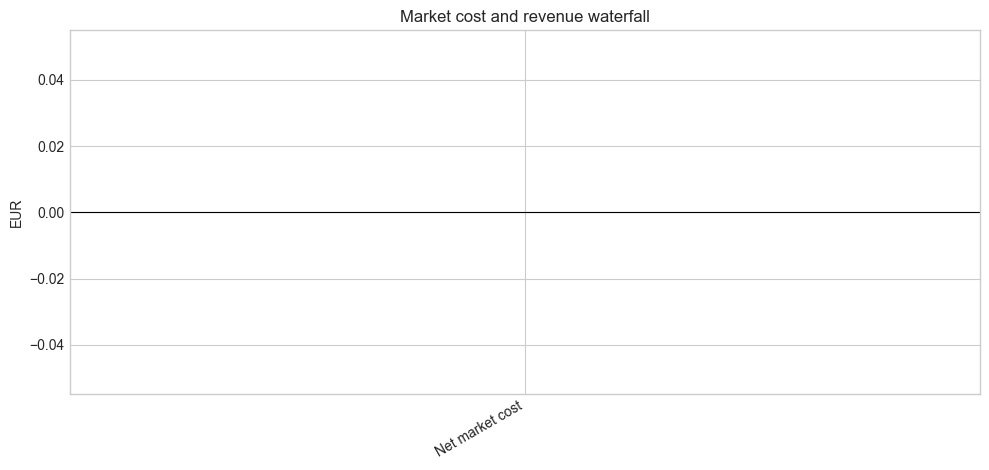

In [15]:
if not market.empty:
    components = {
        "Day-ahead electricity": weighted_value(
            market,
            "day_ahead_position_MWh_el",
            "day_ahead_delivered_price_EUR_per_MWh_el",
        ),
        "Intraday buy": weighted_value(
            market,
            "intraday_buy_MWh_el",
            "intraday_delivered_price_EUR_per_MWh_el",
        ),
        "Intraday sell": -weighted_value(
            market,
            "intraday_sell_MWh_el",
            "intraday_delivered_price_EUR_per_MWh_el",
        ),
        "aFRR energy settlement": weighted_value(
            market,
            "afrr_energy_activated_MWh_el",
            "afrr_energy_delivered_price_EUR_per_MWh_el",
        ),
        "aFRR capacity revenue": -column_sum(market, "afrr_capacity_revenue_EUR"),
    }
else:
    components = {
        "Electricity market cost": column_sum(dispatch, "electricity_market_cost_EUR"),
        "Additional electricity charges": column_sum(
            dispatch, "additional_electricity_charges_cost_EUR"
        ),
        "aFRR capacity revenue": -column_sum(dispatch, "afrr_capacity_revenue_EUR"),
    }

waterfall_df = pd.DataFrame(
    {"component": components.keys(), "value_EUR": components.values()}
).query("value_EUR != 0")
waterfall_df.loc[len(waterfall_df)] = ["Net market cost", waterfall_df["value_EUR"].sum()]

display(waterfall_df)

running = waterfall_df["value_EUR"].iloc[:-1].cumsum().shift(fill_value=0.0)
values = waterfall_df["value_EUR"].iloc[:-1]
labels = waterfall_df["component"].iloc[:-1].tolist()
net = waterfall_df["value_EUR"].iloc[-1]

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ["#D95F02" if value >= 0 else "#1B9E77" for value in values]
ax.bar(labels, values, bottom=running, color=colors)
ax.bar(["Net market cost"], [net], color="#4C78A8")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("EUR")
ax.set_title("Market cost and revenue waterfall")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Optional: per-plant market procurement

Useful when the output contains several plants/routes.

In [16]:
if not market.empty and "plant_name" in market.columns:
    per_plant = market.groupby("plant_name", dropna=False).agg(
        day_ahead_MWh=("day_ahead_position_MWh_el", "sum"),
        afrr_activated_MWh=("afrr_energy_activated_MWh_el", "sum"),
        capacity_revenue_EUR=("afrr_capacity_revenue_EUR", "sum"),
    )
    display(per_plant)
    per_plant[["day_ahead_MWh", "afrr_activated_MWh"]].plot.bar(
        stacked=True,
        figsize=(10, 4),
        color=["#4C78A8", "#B279A2"],
    )
    plt.ylabel("Electricity [MWh_el]")
    plt.title("Electricity procurement by plant")
    plt.tight_layout()
else:
    print("No market_ledger.csv with plant_name column available.")

No market_ledger.csv with plant_name column available.


## Net cost by plant

Scans every use-case output folder under the configured `RESULTS_ROOT`, calculates net cost for every plant, and adds a portfolio total. It uses the most complete available output: net operating cost including grid fees, net operating cost, total net operating cost, or total variable cost.

In [17]:
def summary_value(row: pd.Series, column: str) -> float | None:
    value = pd.to_numeric(pd.Series([row.get(column)]), errors="coerce").iloc[0]
    return None if pd.isna(value) else float(value)


def net_cost_from_summary(summary: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in summary.iterrows():
        plant_name = row.get("plant_name", "unnamed plant")
        gross_cost = summary_value(row, "gross_operating_cost_EUR")
        variable_cost = summary_value(row, "total_variable_cost_EUR")
        net_incl_grid_fees = summary_value(row, "net_operating_cost_incl_grid_fees_EUR")
        net_cost = summary_value(row, "net_operating_cost_EUR")
        total_net_cost = summary_value(row, "total_net_operating_cost_EUR")

        # Steel cost-minimisation has no market settlement columns: its
        # total_variable_cost_EUR is the complete process cost. Do not use
        # the zero-filled net-operating-cost placeholder in that case.
        if gross_cost is not None and abs(gross_cost) > 1e-9:
            if net_incl_grid_fees is not None:
                cost, basis = net_incl_grid_fees, "net operating cost incl. grid fees"
            elif net_cost is not None:
                cost, basis = net_cost, "net operating cost"
            else:
                cost, basis = gross_cost, "gross operating cost"
        elif total_net_cost is not None:
            cost, basis = total_net_cost, "total net operating cost"
        elif variable_cost is not None:
            cost, basis = variable_cost, "total variable cost"
        else:
            print(f"Skipping {plant_name}: no recognised cost column in summary_indicators.csv.")
            continue

        records.append({"plant_name": plant_name, "net_cost_EUR": cost, "cost_basis": basis})
    return pd.DataFrame(records)


OUTPUT_ROOT = RESULTS_ROOT.resolve()
summary_paths = sorted(
    path
    for path in OUTPUT_ROOT.glob("*/summary_indicators.csv")
    if path.parent.name.startswith(ANALYSIS_SCENARIO_PREFIXES)
)

if not summary_paths:
    print(f"No summary_indicators.csv files found under {OUTPUT_ROOT}.")
else:
    cost_frames = []
    for summary_path in summary_paths:
        case_summary = pd.read_csv(summary_path)
        if "plant_name" not in case_summary.columns:
            print(f"Skipping {summary_path.parent.name}: no plant_name column.")
            continue

        case_costs = net_cost_from_summary(case_summary)
        if case_costs.empty:
            print(f"Skipping {summary_path.parent.name}: no recognised cost values.")
            continue

        case_costs.insert(0, "output_folder", summary_path.parent.name)
        cost_frames.append(case_costs)

    if not cost_frames:
        print("No recognised net-cost values were found in the output folders.")
    else:
        net_cost_by_plant = pd.concat(cost_frames, ignore_index=True)
        portfolio_total = net_cost_by_plant["net_cost_EUR"].sum()
        net_cost_by_plant.loc[len(net_cost_by_plant)] = {
            "output_folder": "All output folders",
            "plant_name": "All plants",
            "net_cost_EUR": portfolio_total,
            "cost_basis": "portfolio total",
        }
        net_cost_by_plant["net_cost_MEUR"] = net_cost_by_plant["net_cost_EUR"] / 1_000_000
        net_cost_by_plant["net_cost_BEUR"] = net_cost_by_plant["net_cost_EUR"] / 1_000_000_000
        display(
            net_cost_by_plant.style.format(
                {
                    "net_cost_EUR": "{:,.2f}",
                    "net_cost_MEUR": "{:,.2f}",
                    "net_cost_BEUR": "{:,.3f}",
                }
            )
        )

,output_folder,plant_name,net_cost_EUR,cost_basis,net_cost_MEUR,net_cost_BEUR
0,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120423_bf_bof_coal_external,"559,224,952.74",total variable cost,559.22,0.559
1,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120426_bf_bof_coal_external,"1,522,034,551.24",total variable cost,"1,522.03",1.522
2,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120421_bf_bof_coal_external,"4,027,863,068.80",total variable cost,"4,027.86",4.028
3,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120422_bf_bof_coal_external,"1,885,609,822.41",total variable cost,"1,885.61",1.886
4,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120427_bf_bof_coal_external,"392,783,109.92",total variable cost,392.78,0.393
5,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120432_bf_bof_coal_external,"1,071,806,911.22",total variable cost,"1,071.81",1.072
6,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120425_bf_bof_coal_external,"883,761,997.54",total variable cost,883.76,0.884
7,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120428_bf_bof_coal_external,"490,978,887.62",total variable cost,490.98,0.491
8,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120424_bf_bof_coal_external,"2,308,428,761.16",total variable cost,"2,308.43",2.308
9,aktuellepolitiken_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120423_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"440,211,065.64",total variable cost,440.21,0.440


## Temporary CO2, labour, maintenance, and network-cost correction

Scan all completed steel output folders and calculate annual net cost including temporarily missing fuel-related CO2 costs, labour at **38 EUR/t steel**, maintenance at **2.37 EUR/t steel**, fuel-network capacity tariffs, and the electricity-grid capacity tariff. The electricity tariff is **11.39 EUR/kW/year below 2,500 full-load hours** and **53.06 EUR/kW/year from 2,500 hours**. At 7,000, 7,500, and 8,000 hours, respectively, the payable tariff is reduced to **20%, 15%, and 10%** of the published rate. The temporary CO2 addition is not applied to `aktuellepolitiken`, `hohenachfrage`, or `niedrigenachfrage`, because those simulations already include corrected fuel-emission factors and CO2 cost. This analysis does not modify simulation results.

In [18]:
from pathlib import Path

import pandas as pd
from IPython.display import display

# Temporary annual-cost correction for currently omitted CO2 and fixed operating costs.
# These provisional direct-combustion factors must later be replaced by explicit,
# literature-grounded coal_co2_factor and natural_gas_co2_factor input columns.
# External-hydrogen plants also receive the annual peak-capacity network tariff below.
TEMP_COAL_CO2_FACTOR_T_PER_MWH = 0.34
TEMP_NATURAL_GAS_CO2_FACTOR_T_PER_MWH = 0.20
CO2_COST_ALREADY_INCLUDED_PREFIXES = (
    "aktuellepolitiken_",
    "hohenachfrage_",
    "niedrigenachfrage_",
)
LABOUR_COST_EUR_PER_T = 38.0
MAINTENANCE_COST_EUR_PER_T = 2.37
HYDROGEN_NETWORK_TARIFF_EUR_PER_KW_A = 25.0
NATURAL_GAS_NETWORK_TARIFF_EUR_PER_KW_A = 7.06
ELECTRICITY_GRID_TARIFF_LOW_EUR_PER_KW_A = 11.39
ELECTRICITY_GRID_TARIFF_HIGH_EUR_PER_KW_A = 53.06


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the FLEXIMOD project root from the current working directory."
    )


PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = Path(
    r"C:\Users\khm\ownCloud\Dropbox\Ph.D\My publications\Journal paper\4\Data\Results\steel plant"
).resolve()
INPUT_ROOT = PROJECT_ROOT / "data" / "input"


def input_case_for_output(output_folder: Path) -> Path | None:
    candidates = [
        case_dir
        for case_dir in INPUT_ROOT.iterdir()
        if case_dir.is_dir() and output_folder.name.startswith(f"{case_dir.name}_")
    ]
    return max(candidates, key=lambda path: len(path.name), default=None)


def temporary_summary_value(row: pd.Series, column: str) -> float | None:
    value = pd.to_numeric(pd.Series([row.get(column)]), errors="coerce").iloc[0]
    return None if pd.isna(value) else float(value)


def temporary_net_cost_from_summary(case_summary: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in case_summary.iterrows():
        plant_name = row.get("plant_name", "unnamed plant")
        gross_cost = temporary_summary_value(row, "gross_operating_cost_EUR")
        variable_cost = temporary_summary_value(row, "total_variable_cost_EUR")
        net_cost = temporary_summary_value(row, "net_operating_cost_EUR")
        total_net_cost = temporary_summary_value(row, "total_net_operating_cost_EUR")

        if gross_cost is not None and abs(gross_cost) > 1e-9:
            # Start before the ex-post grid-capacity settlement because this
            # cell calculates that capacity charge explicitly below.
            cost = net_cost if net_cost is not None else gross_cost
        elif total_net_cost is not None:
            cost = total_net_cost
        elif variable_cost is not None:
            cost = variable_cost
        else:
            continue
        records.append({"plant_name": plant_name, "original_net_cost_EUR": cost})
    return pd.DataFrame(records)


original_cost_frames = []
for summary_path in sorted(OUTPUT_ROOT.glob("*/summary_indicators.csv")):
    case_costs = temporary_net_cost_from_summary(pd.read_csv(summary_path))
    if case_costs.empty:
        continue
    case_costs.insert(0, "output_folder", summary_path.parent.name)
    original_cost_frames.append(case_costs)

original_costs = (
    pd.concat(original_cost_frames, ignore_index=True)
    if original_cost_frames
    else pd.DataFrame(columns=["output_folder", "plant_name", "original_net_cost_EUR"])
)

correction_records = []
for output_folder in sorted(
    path
    for path in OUTPUT_ROOT.iterdir()
    if path.is_dir() and path.name.startswith(CO2_COST_ALREADY_INCLUDED_PREFIXES)
):
    dispatch_path = output_folder / "dispatch_results.csv"
    input_case = input_case_for_output(output_folder)
    if not dispatch_path.exists() or input_case is None:
        continue
    co2_cost_already_included = output_folder.name.startswith(CO2_COST_ALREADY_INCLUDED_PREFIXES)

    forecasts_path = input_case / "forecasts_df.csv"
    plants_path = input_case / "plants.csv"
    if not forecasts_path.exists() or not plants_path.exists():
        print(f"Skipping {output_folder.name}: forecasts_df.csv or plants.csv was not found.")
        continue

    plant_technologies = pd.read_csv(plants_path, usecols=["name", "technology"])
    electrolyser_plants = set(
        plant_technologies.loc[
            plant_technologies["technology"].astype(str).str.lower().eq("electrolyser"),
            "name",
        ].astype(str)
    )

    dispatch_columns = [
        "datetime",
        "plant_name",
        "steel_route",
        "steel_output_t",
        "total_electricity_consumption_MWh",
        "coal_consumption_MWh",
        "natural_gas_consumption_MWh",
        "hydrogen_consumption_MWh",
    ]
    try:
        case_dispatch = pd.read_csv(dispatch_path, usecols=dispatch_columns)
        case_forecasts = pd.read_csv(
            forecasts_path,
            usecols=["datetime", "co2_price"],
        )
    except (OSError, ValueError, pd.errors.ParserError) as exc:
        print(f"Skipping {output_folder.name}: {exc}")
        continue

    case_dispatch["datetime"] = pd.to_datetime(case_dispatch["datetime"], errors="raise")
    unique_timestamps = case_dispatch["datetime"].drop_duplicates().sort_values()
    positive_timestep_deltas = unique_timestamps.diff().dropna().dt.total_seconds() / 3600.0
    positive_timestep_deltas = positive_timestep_deltas[positive_timestep_deltas > 0]
    if positive_timestep_deltas.empty:
        raise ValueError(f"{output_folder.name}: cannot infer the dispatch timestep")
    timestep_hours = float(positive_timestep_deltas.median())
    case_forecasts["datetime"] = pd.to_datetime(case_forecasts["datetime"], errors="raise")
    case_forecasts["co2_price"] = pd.to_numeric(case_forecasts["co2_price"], errors="raise")
    case_forecasts = case_forecasts.drop_duplicates("datetime")
    corrected = case_dispatch.merge(
        case_forecasts,
        on="datetime",
        how="left",
        validate="many_to_one",
    )
    if corrected["co2_price"].isna().any():
        missing = int(corrected["co2_price"].isna().sum())
        raise ValueError(
            f"{output_folder.name}: {missing} dispatch rows have no matching CO2 price"
        )

    coal = pd.to_numeric(corrected["coal_consumption_MWh"], errors="coerce").fillna(0.0)
    natural_gas = pd.to_numeric(corrected["natural_gas_consumption_MWh"], errors="coerce").fillna(
        0.0
    )
    route = corrected["steel_route"].astype(str).str.lower()
    corrected["steel_output_t"] = pd.to_numeric(
        corrected["steel_output_t"], errors="coerce"
    ).fillna(0.0)
    corrected["hydrogen_consumption_MWh"] = pd.to_numeric(
        corrected["hydrogen_consumption_MWh"], errors="coerce"
    ).fillna(0.0)
    corrected["total_electricity_consumption_MWh"] = pd.to_numeric(
        corrected["total_electricity_consumption_MWh"], errors="coerce"
    ).fillna(0.0)

    # Only legacy outputs receive the provisional CO2 correction. The three
    # corrected scenario families already include explicit fuel-emission factors
    # and CO2 prices in their simulated net operating cost.
    corrected["temporary_co2_correction_applied"] = not co2_cost_already_included
    corrected["temporary_missing_co2_emissions_t"] = 0.0
    dri_route = route.isin(["dri_eaf", "dri_bof"])
    bf_bof_route = route.eq("bf_bof")
    if not co2_cost_already_included:
        # DRI natural gas is not corrected because its legacy 0.5 tCO2/MWh
        # default is already included in the legacy simulated net cost.
        corrected.loc[dri_route, "temporary_missing_co2_emissions_t"] = (
            coal[dri_route] * TEMP_COAL_CO2_FACTOR_T_PER_MWH
        )
        corrected.loc[bf_bof_route, "temporary_missing_co2_emissions_t"] = (
            coal[bf_bof_route] * TEMP_COAL_CO2_FACTOR_T_PER_MWH
            + natural_gas[bf_bof_route] * TEMP_NATURAL_GAS_CO2_FACTOR_T_PER_MWH
        )
    corrected["temporary_missing_co2_cost_EUR"] = (
        corrected["temporary_missing_co2_emissions_t"] * corrected["co2_price"]
    )
    corrected["labour_cost_EUR"] = corrected["steel_output_t"] * LABOUR_COST_EUR_PER_T
    corrected["maintenance_cost_EUR"] = corrected["steel_output_t"] * MAINTENANCE_COST_EUR_PER_T
    corrected["uses_external_hydrogen"] = corrected["hydrogen_consumption_MWh"].gt(
        0.0
    ) & ~corrected["plant_name"].astype(str).isin(electrolyser_plants)
    corrected["external_hydrogen_withdrawal_MW"] = (
        corrected["hydrogen_consumption_MWh"] / timestep_hours
    ).where(corrected["uses_external_hydrogen"], 0.0)
    corrected["natural_gas_withdrawal_MW"] = natural_gas / timestep_hours
    corrected["electricity_withdrawal_MW"] = (
        corrected["total_electricity_consumption_MWh"] / timestep_hours
    )

    per_plant_correction = corrected.groupby(
        ["plant_name", "steel_route"], as_index=False, dropna=False
    ).agg(
        temporary_co2_correction_applied=("temporary_co2_correction_applied", "first"),
        annual_steel_output_t=("steel_output_t", "sum"),
        temporary_missing_co2_emissions_t=(
            "temporary_missing_co2_emissions_t",
            "sum",
        ),
        temporary_missing_co2_cost_EUR=("temporary_missing_co2_cost_EUR", "sum"),
        labour_cost_EUR=("labour_cost_EUR", "sum"),
        maintenance_cost_EUR=("maintenance_cost_EUR", "sum"),
        external_hydrogen_peak_MW=("external_hydrogen_withdrawal_MW", "max"),
        natural_gas_peak_MW=("natural_gas_withdrawal_MW", "max"),
        annual_electricity_demand_MWh=("total_electricity_consumption_MWh", "sum"),
        electricity_peak_MW=("electricity_withdrawal_MW", "max"),
    )
    per_plant_correction["hydrogen_network_tariff_EUR_per_kW_a"] = (
        HYDROGEN_NETWORK_TARIFF_EUR_PER_KW_A
    )
    per_plant_correction["annual_hydrogen_network_cost_EUR"] = (
        per_plant_correction["external_hydrogen_peak_MW"]
        * 1_000.0
        * HYDROGEN_NETWORK_TARIFF_EUR_PER_KW_A
    )
    per_plant_correction["natural_gas_network_tariff_EUR_per_kW_a"] = (
        NATURAL_GAS_NETWORK_TARIFF_EUR_PER_KW_A
    )
    per_plant_correction["annual_natural_gas_network_cost_EUR"] = (
        per_plant_correction["natural_gas_peak_MW"]
        * 1_000.0
        * NATURAL_GAS_NETWORK_TARIFF_EUR_PER_KW_A
    )
    per_plant_correction["electricity_full_load_hours"] = (
        per_plant_correction["annual_electricity_demand_MWh"]
        .div(
            per_plant_correction["electricity_peak_MW"].where(
                per_plant_correction["electricity_peak_MW"].gt(0.0)
            )
        )
        .fillna(0.0)
    )
    per_plant_correction["electricity_grid_published_tariff_EUR_per_kW_a"] = (
        ELECTRICITY_GRID_TARIFF_LOW_EUR_PER_KW_A
    )
    high_grid_tier = per_plant_correction["electricity_full_load_hours"].ge(2_500.0)
    per_plant_correction.loc[high_grid_tier, "electricity_grid_published_tariff_EUR_per_kW_a"] = (
        ELECTRICITY_GRID_TARIFF_HIGH_EUR_PER_KW_A
    )
    per_plant_correction["electricity_grid_payable_share"] = 1.0
    per_plant_correction.loc[
        per_plant_correction["electricity_full_load_hours"].ge(7_000.0),
        "electricity_grid_payable_share",
    ] = 0.20
    per_plant_correction.loc[
        per_plant_correction["electricity_full_load_hours"].ge(7_500.0),
        "electricity_grid_payable_share",
    ] = 0.15
    per_plant_correction.loc[
        per_plant_correction["electricity_full_load_hours"].ge(8_000.0),
        "electricity_grid_payable_share",
    ] = 0.10
    per_plant_correction["electricity_grid_effective_tariff_EUR_per_kW_a"] = (
        per_plant_correction["electricity_grid_published_tariff_EUR_per_kW_a"]
        * per_plant_correction["electricity_grid_payable_share"]
    )
    per_plant_correction["annual_electricity_grid_capacity_cost_EUR"] = (
        per_plant_correction["electricity_peak_MW"]
        * 1_000.0
        * per_plant_correction["electricity_grid_effective_tariff_EUR_per_kW_a"]
    )
    per_plant_correction.insert(0, "output_folder", output_folder.name)
    correction_records.append(per_plant_correction)

if not correction_records:
    print("No completed steel dispatch outputs were found for CO2-cost correction.")
else:
    temporary_co2_correction = pd.concat(correction_records, ignore_index=True)
    adjusted_net_cost_by_plant = original_costs.merge(
        temporary_co2_correction,
        on=["output_folder", "plant_name"],
        how="inner",
        validate="one_to_one",
    )
    adjusted_net_cost_by_plant["adjusted_net_cost_EUR"] = (
        adjusted_net_cost_by_plant["original_net_cost_EUR"]
        + adjusted_net_cost_by_plant["temporary_missing_co2_cost_EUR"]
        + adjusted_net_cost_by_plant["labour_cost_EUR"]
        + adjusted_net_cost_by_plant["maintenance_cost_EUR"]
        + adjusted_net_cost_by_plant["annual_hydrogen_network_cost_EUR"]
        + adjusted_net_cost_by_plant["annual_natural_gas_network_cost_EUR"]
        + adjusted_net_cost_by_plant["annual_electricity_grid_capacity_cost_EUR"]
    )
    adjusted_net_cost_by_plant["adjusted_net_cost_MEUR"] = (
        adjusted_net_cost_by_plant["adjusted_net_cost_EUR"] / 1_000_000
    )
    adjusted_net_cost_by_plant["adjusted_net_cost_BEUR"] = (
        adjusted_net_cost_by_plant["adjusted_net_cost_EUR"] / 1_000_000_000
    )

    total_columns = [
        "original_net_cost_EUR",
        "annual_steel_output_t",
        "temporary_missing_co2_emissions_t",
        "temporary_missing_co2_cost_EUR",
        "labour_cost_EUR",
        "maintenance_cost_EUR",
        "external_hydrogen_peak_MW",
        "annual_hydrogen_network_cost_EUR",
        "natural_gas_peak_MW",
        "annual_natural_gas_network_cost_EUR",
        "annual_electricity_demand_MWh",
        "electricity_peak_MW",
        "annual_electricity_grid_capacity_cost_EUR",
        "adjusted_net_cost_EUR",
        "adjusted_net_cost_MEUR",
        "adjusted_net_cost_BEUR",
    ]
    total_row = {
        "output_folder": "All output folders",
        "plant_name": "All plants",
        "steel_route": "portfolio total",
        "hydrogen_network_tariff_EUR_per_kW_a": HYDROGEN_NETWORK_TARIFF_EUR_PER_KW_A,
        "natural_gas_network_tariff_EUR_per_kW_a": NATURAL_GAS_NETWORK_TARIFF_EUR_PER_KW_A,
        "electricity_full_load_hours": float("nan"),
        "electricity_grid_published_tariff_EUR_per_kW_a": float("nan"),
        "electricity_grid_payable_share": float("nan"),
        "electricity_grid_effective_tariff_EUR_per_kW_a": float("nan"),
        **{column: adjusted_net_cost_by_plant[column].sum() for column in total_columns},
    }
    adjusted_net_cost_by_plant.loc[len(adjusted_net_cost_by_plant)] = total_row
    display(
        adjusted_net_cost_by_plant.style.format(
            {
                "original_net_cost_EUR": "{:,.2f}",
                "annual_steel_output_t": "{:,.2f}",
                "temporary_missing_co2_emissions_t": "{:,.2f}",
                "temporary_missing_co2_cost_EUR": "{:,.2f}",
                "labour_cost_EUR": "{:,.2f}",
                "maintenance_cost_EUR": "{:,.2f}",
                "external_hydrogen_peak_MW": "{:,.3f}",
                "hydrogen_network_tariff_EUR_per_kW_a": "{:,.2f}",
                "annual_hydrogen_network_cost_EUR": "{:,.2f}",
                "natural_gas_peak_MW": "{:,.3f}",
                "natural_gas_network_tariff_EUR_per_kW_a": "{:,.2f}",
                "annual_natural_gas_network_cost_EUR": "{:,.2f}",
                "annual_electricity_demand_MWh": "{:,.2f}",
                "electricity_peak_MW": "{:,.3f}",
                "electricity_full_load_hours": "{:,.1f}",
                "electricity_grid_published_tariff_EUR_per_kW_a": "{:,.2f}",
                "electricity_grid_payable_share": "{:.0%}",
                "electricity_grid_effective_tariff_EUR_per_kW_a": "{:,.2f}",
                "annual_electricity_grid_capacity_cost_EUR": "{:,.2f}",
                "adjusted_net_cost_EUR": "{:,.2f}",
                "adjusted_net_cost_MEUR": "{:,.2f}",
                "adjusted_net_cost_BEUR": "{:,.3f}",
            }
        )
    )

,output_folder,plant_name,original_net_cost_EUR,steel_route,temporary_co2_correction_applied,annual_steel_output_t,temporary_missing_co2_emissions_t,temporary_missing_co2_cost_EUR,labour_cost_EUR,maintenance_cost_EUR,external_hydrogen_peak_MW,natural_gas_peak_MW,annual_electricity_demand_MWh,electricity_peak_MW,hydrogen_network_tariff_EUR_per_kW_a,annual_hydrogen_network_cost_EUR,natural_gas_network_tariff_EUR_per_kW_a,annual_natural_gas_network_cost_EUR,electricity_full_load_hours,electricity_grid_published_tariff_EUR_per_kW_a,electricity_grid_payable_share,electricity_grid_effective_tariff_EUR_per_kW_a,annual_electricity_grid_capacity_cost_EUR,adjusted_net_cost_EUR,adjusted_net_cost_MEUR,adjusted_net_cost_BEUR
0,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120423_bf_bof_coal_external,"559,224,952.74",bf_bof,False,"1,239,279.26",0.00,0.00,"47,092,611.93","2,937,091.85",0.000,0.000,"123,927.93",15.229,25.00,0.00,7.06,0.00,"8,137.7",53.06,10%,5.31,"80,804.74","609,335,461.26",609.34,0.609
1,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120426_bf_bof_coal_external,"1,522,034,551.24",bf_bof,False,"3,372,928.63",0.00,0.00,"128,171,287.96","7,993,840.85",0.000,0.000,"337,292.86",41.448,25.00,0.00,7.06,0.00,"8,137.7",53.06,10%,5.31,"219,925.10","1,658,419,605.16","1,658.42",1.658
2,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120421_bf_bof_coal_external,"4,027,863,068.80",bf_bof,False,"8,921,940.25",0.00,0.00,"339,033,729.45","21,144,998.39",0.000,0.000,"892,194.02",105.511,25.00,0.00,7.06,0.00,"8,456.0",53.06,10%,5.31,"559,839.82","4,388,601,636.45","4,388.60",4.389
3,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120422_bf_bof_coal_external,"1,885,609,822.41",bf_bof,False,"4,176,569.61",0.00,0.00,"158,709,645.31","9,898,469.98",0.000,0.000,"417,656.96",49.239,25.00,0.00,7.06,0.00,"8,482.2",53.06,10%,5.31,"261,264.17","2,054,479,201.87","2,054.48",2.054
4,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120427_bf_bof_coal_external,"392,783,109.92",bf_bof,False,"870,433.19",0.00,0.00,"33,076,461.41","2,062,926.67",0.000,0.000,"87,043.32",10.696,25.00,0.00,7.06,0.00,"8,137.7",53.06,10%,5.31,"56,754.86","427,979,252.87",427.98,0.428
5,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120432_bf_bof_coal_external,"1,071,806,911.22",bf_bof,False,"2,375,194.58",0.00,0.00,"90,257,394.05","5,629,211.16",0.000,0.000,"237,519.46",29.188,25.00,0.00,7.06,0.00,"8,137.7",53.06,10%,5.31,"154,869.84","1,167,848,386.26","1,167.85",1.168
6,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120425_bf_bof_coal_external,"883,761,997.54",bf_bof,False,"1,958,474.69",0.00,0.00,"74,422,038.19","4,641,585.01",0.000,0.000,"195,847.47",24.067,25.00,0.00,7.06,0.00,"8,137.7",53.06,10%,5.31,"127,698.45","962,953,319.18",962.95,0.963
7,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120428_bf_bof_coal_external,"490,978,887.62",bf_bof,False,"1,088,041.49",0.00,0.00,"41,345,576.78","2,578,658.34",0.000,0.000,"108,804.15",13.370,25.00,0.00,7.06,0.00,"8,137.7",53.06,10%,5.31,"70,943.58","534,974,066.32",534.97,0.535
8,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120424_bf_bof_coal_external,"2,308,428,761.16",bf_bof,False,"5,113,795.02",0.00,0.00,"194,324,210.78","12,119,694.20",0.000,0.000,"511,379.50",60.962,25.00,0.00,7.06,0.00,"8,388.5",53.06,10%,5.31,"323,463.00","2,515,196,129.14","2,515.20",2.515
9,aktuellepolitiken_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120423_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,"440,211,065.64",bf_bof,False,"1,239,279.26",0.00,0.00,"47,092,611.93","2,937,091.85",0.000,371.586,"3,295,768.85",504.730,25.00,0.00,7.06,"2,623,397.60","6,529.8",53.06,100%,53.06,"26,780,999.06","519,645,166.08",519.65,0.520


## Energy demand by carrier and plant

Scan every completed output folder and report electricity, coal, natural-gas, and hydrogen demand for each plant in MWh and GWh, including carrier shares and total final energy.

In [19]:
# Energy demand by carrier for every plant in every completed output folder.
# The aggregate dispatch columns are used to avoid double-counting technology-level flows.
from pathlib import Path

import pandas as pd
from IPython.display import display


def find_fleximod_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the FLEXIMOD project root.")


PROJECT_ROOT_ENERGY = find_fleximod_root()
OUTPUT_ROOT_ENERGY = Path(
    r"C:\Users\khm\ownCloud\Dropbox\Ph.D\My publications\Journal paper\4\Data\Results\steel plant"
).resolve()

# Authoritative aggregate columns and their physical carrier units.
CARRIER_COLUMNS = {
    "Electricity": ("total_electricity_consumption_MWh", "MWh_el"),
    "Coal": ("coal_consumption_MWh", "MWh_fuel"),
    "Natural gas": ("natural_gas_consumption_MWh", "MWh_fuel"),
    "Hydrogen": ("hydrogen_consumption_MWh", "MWh_H2"),
}

ANALYSIS_SCENARIO_PREFIXES_ENERGY = (
    "aktuellepolitiken_",
    "hohenachfrage_",
    "niedrigenachfrage_",
)

energy_records = []
dispatch_files = sorted(
    path
    for path in OUTPUT_ROOT_ENERGY.glob("*/dispatch_results.csv")
    if path.parent.name.startswith(ANALYSIS_SCENARIO_PREFIXES_ENERGY)
)
unreadable_dispatch_files = []

for dispatch_file in dispatch_files:
    try:
        available_columns = set(pd.read_csv(dispatch_file, nrows=0).columns)
    except (OSError, pd.errors.ParserError) as exc:
        unreadable_dispatch_files.append((dispatch_file, exc))
        print(f"Skipping unreadable dispatch file: {dispatch_file} ({exc})")
        continue
    carrier_columns = {
        carrier: (column, unit)
        for carrier, (column, unit) in CARRIER_COLUMNS.items()
        if column in available_columns
    }
    if "plant_name" not in available_columns or not carrier_columns:
        continue

    identity_columns = ["plant_name"]
    for optional_column in ("plant_type", "steel_route"):
        if optional_column in available_columns:
            identity_columns.append(optional_column)

    usecols = identity_columns + [column for column, _ in carrier_columns.values()]
    try:
        data = pd.read_csv(dispatch_file, usecols=usecols)
    except (OSError, pd.errors.ParserError) as exc:
        unreadable_dispatch_files.append((dispatch_file, exc))
        print(f"Skipping unreadable dispatch file: {dispatch_file} ({exc})")
        continue
    for column, _ in carrier_columns.values():
        data[column] = pd.to_numeric(data[column], errors="coerce").fillna(0.0)

    grouped = data.groupby(identity_columns, dropna=False, as_index=False).sum(numeric_only=True)
    for _, plant in grouped.iterrows():
        for carrier, (column, unit) in carrier_columns.items():
            energy_records.append(
                {
                    "output_folder": dispatch_file.parent.name,
                    "plant_name": plant["plant_name"],
                    "plant_type": plant.get("plant_type", ""),
                    "steel_route": plant.get("steel_route", ""),
                    "energy_carrier": carrier,
                    "carrier_unit": unit,
                    "energy_demand_MWh": float(plant[column]),
                }
            )

if unreadable_dispatch_files:
    print(f"Skipped {len(unreadable_dispatch_files)} unreadable dispatch file(s).")

energy_demand_by_carrier = pd.DataFrame(energy_records)

if energy_demand_by_carrier.empty:
    print(
        f"No dispatch results containing supported energy-carrier columns found under {OUTPUT_ROOT_ENERGY}"
    )
else:
    energy_demand_by_carrier["energy_demand_GWh"] = (
        energy_demand_by_carrier["energy_demand_MWh"] / 1_000.0
    )
    plant_totals = energy_demand_by_carrier.groupby(["output_folder", "plant_name"], dropna=False)[
        "energy_demand_MWh"
    ].transform("sum")
    energy_demand_by_carrier["carrier_share_percent"] = (
        energy_demand_by_carrier["energy_demand_MWh"]
        .div(plant_totals.where(plant_totals.ne(0)))
        .mul(100.0)
        .fillna(0.0)
    )

    energy_demand_by_carrier = energy_demand_by_carrier.sort_values(
        ["output_folder", "plant_name", "energy_carrier"]
    ).reset_index(drop=True)

    print(
        f"Energy demand by carrier: {energy_demand_by_carrier['plant_name'].nunique()} unique plant name(s) "
        f"across {energy_demand_by_carrier['output_folder'].nunique()} completed output folder(s)."
    )
    display(
        energy_demand_by_carrier.style.format(
            {
                "energy_demand_MWh": "{:,.2f}",
                "energy_demand_GWh": "{:,.3f}",
                "carrier_share_percent": "{:,.2f}%",
            }
        )
    )

    # Compact plant-by-carrier view; values are GWh over the simulated period.
    energy_demand_pivot_GWh = (
        energy_demand_by_carrier.pivot_table(
            index=["output_folder", "plant_name", "steel_route"],
            columns="energy_carrier",
            values="energy_demand_GWh",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reset_index()
        .rename_axis(columns=None)
    )
    carrier_value_columns = [
        column for column in CARRIER_COLUMNS if column in energy_demand_pivot_GWh.columns
    ]
    energy_demand_pivot_GWh["Total final energy"] = energy_demand_pivot_GWh[
        carrier_value_columns
    ].sum(axis=1)
    display(
        energy_demand_pivot_GWh.style.format(
            {column: "{:,.3f}" for column in carrier_value_columns + ["Total final energy"]}
        )
    )

Energy demand by carrier: 153 unique plant name(s) across 97 completed output folder(s).


,output_folder,plant_name,plant_type,steel_route,energy_carrier,carrier_unit,energy_demand_MWh,energy_demand_GWh,carrier_share_percent
0,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120421_bf_bof_coal_external,steel_plant,bf_bof,Coal,MWh_fuel,"31,226,790.87","31,226.791",97.22%
1,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120421_bf_bof_coal_external,steel_plant,bf_bof,Electricity,MWh_el,"892,194.02",892.194,2.78%
2,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120421_bf_bof_coal_external,steel_plant,bf_bof,Hydrogen,MWh_H2,0.00,0.000,0.00%
3,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120421_bf_bof_coal_external,steel_plant,bf_bof,Natural gas,MWh_fuel,0.00,0.000,0.00%
4,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120422_bf_bof_coal_external,steel_plant,bf_bof,Coal,MWh_fuel,"14,617,993.65","14,617.994",97.22%
5,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120422_bf_bof_coal_external,steel_plant,bf_bof,Electricity,MWh_el,"417,656.96",417.657,2.78%
6,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120422_bf_bof_coal_external,steel_plant,bf_bof,Hydrogen,MWh_H2,0.00,0.000,0.00%
7,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120422_bf_bof_coal_external,steel_plant,bf_bof,Natural gas,MWh_fuel,0.00,0.000,0.00%
8,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120423_bf_bof_coal_external,steel_plant,bf_bof,Coal,MWh_fuel,"4,337,477.41","4,337.477",97.22%
9,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120423_bf_bof_coal_external,steel_plant,bf_bof,Electricity,MWh_el,"123,927.93",123.928,2.78%


,output_folder,plant_name,steel_route,Coal,Electricity,Hydrogen,Natural gas,Total final energy
0,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120421_bf_bof_coal_external,bf_bof,"31,226.791",892.194,0.000,0.000,"32,118.985"
1,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120422_bf_bof_coal_external,bf_bof,"14,617.994",417.657,0.000,0.000,"15,035.651"
2,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120423_bf_bof_coal_external,bf_bof,"4,337.477",123.928,0.000,0.000,"4,461.405"
3,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120424_bf_bof_coal_external,bf_bof,"17,898.283",511.380,0.000,0.000,"18,409.662"
4,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120425_bf_bof_coal_external,bf_bof,"6,854.661",195.847,0.000,0.000,"7,050.509"
5,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120426_bf_bof_coal_external,bf_bof,"11,805.250",337.293,0.000,0.000,"12,142.543"
6,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120427_bf_bof_coal_external,bf_bof,"3,046.516",87.043,0.000,0.000,"3,133.560"
7,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120428_bf_bof_coal_external,bf_bof,"3,808.145",108.804,0.000,0.000,"3,916.949"
8,aktuellepolitiken_2030_bf_bof_coal_external_steel_cost_minimization,P100000120432_bf_bof_coal_external,bf_bof,"8,313.181",237.519,0.000,0.000,"8,550.700"
9,aktuellepolitiken_2030_bf_bof_hybrid_hydrogen_natural_gas_electrolyser_steel_cost_minimization,P100000120421_bf_bof_hybrid_hydrogen_natural_gas_electrolyser,bf_bof,0.000,"22,985.862","15,465.568","4,997.985","43,449.415"


## Export energy demand and net cost to Excel

Set `EXPORT_TO_EXCEL = True` and run this cell after the net-cost and energy-demand cells. The workbook contains separate sheets for adjusted net cost, detailed carrier demand, and the plant-by-carrier energy table.

In [20]:
from pathlib import Path

import pandas as pd

# Change to True when you want to create or replace the Excel workbook.
EXPORT_TO_EXCEL = True
EXCEL_EXPORT_PATH = PROJECT_ROOT_ENERGY / "data" / "output" / "energy_demand_and_net_cost.xlsx"

if not EXPORT_TO_EXCEL:
    print("Excel export is disabled. Set EXPORT_TO_EXCEL = True and run this cell.")
else:
    export_sheets: dict[str, pd.DataFrame] = {}

    if (
        "adjusted_net_cost_by_plant" in globals()
        and isinstance(adjusted_net_cost_by_plant, pd.DataFrame)
        and not adjusted_net_cost_by_plant.empty
    ):
        export_sheets["Adjusted net cost"] = adjusted_net_cost_by_plant.copy()
    elif (
        "net_cost_by_plant" in globals()
        and isinstance(net_cost_by_plant, pd.DataFrame)
        and not net_cost_by_plant.empty
    ):
        export_sheets["Net cost"] = net_cost_by_plant.copy()

    if (
        "energy_demand_by_carrier" in globals()
        and isinstance(energy_demand_by_carrier, pd.DataFrame)
        and not energy_demand_by_carrier.empty
    ):
        export_sheets["Energy by carrier"] = energy_demand_by_carrier.copy()

    if (
        "energy_demand_pivot_GWh" in globals()
        and isinstance(energy_demand_pivot_GWh, pd.DataFrame)
        and not energy_demand_pivot_GWh.empty
    ):
        export_sheets["Energy pivot GWh"] = energy_demand_pivot_GWh.copy()

    if not export_sheets:
        raise RuntimeError(
            "No analysis tables are available. Run the net-cost and energy-demand cells first."
        )

    EXCEL_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    with pd.ExcelWriter(EXCEL_EXPORT_PATH, engine="openpyxl") as writer:
        for sheet_name, table in export_sheets.items():
            table.to_excel(writer, sheet_name=sheet_name, index=False)
            worksheet = writer.sheets[sheet_name]
            worksheet.freeze_panes = "A2"
            worksheet.auto_filter.ref = worksheet.dimensions
            for column_cells in worksheet.columns:
                width = min(60, max(len(str(cell.value or "")) for cell in column_cells) + 2)
                worksheet.column_dimensions[column_cells[0].column_letter].width = width

    print(f"Excel workbook written to: {EXCEL_EXPORT_PATH.resolve()}")
    print("Sheets: " + ", ".join(export_sheets))

Excel workbook written to: C:\Users\khm\Models\FLEXIMOD\data\output\energy_demand_and_net_cost.xlsx
Sheets: Adjusted net cost, Energy by carrier, Energy pivot GWh
